# Squared-Up Above Expected — v2

### What changed from v1, and why

| # | v1 | v2 | Reason |
|---|---|---|---|
| 1 | `player_name` used as batter label | `playerid_reverse_lookup` on `batter` | `player_name` is the **pitcher** in raw Statcast. v1's leaderboard was labelled with whichever pitcher each hitter faced first. |
| 2 | Binary target (`squared_up` at 0.80) | **Continuous target** (`squared_up_pct`) | Binarising a smooth variable at a 66%-base-rate threshold discards most of the information and imposes a binomial noise floor. This was the main cause of v1's poor reliability. |
| 3 | Same-season R² only | **Year-over-year prediction** | v1's marginal test was contaminated: xwOBAcon is derived from exit velocity, and so is squared-up %, so `su_rate` was partly predicting itself. |
| 4 | Full-season aggregates only | **Sample-size sweep** | Pitch difficulty averages out over a season. If the adjustment has value it lives in small samples. |
| 5 | Pitcher null noted in passing | **Permutation test** | Turns "no signal detected" into a testable claim with a p-value. |

Everything that validated in v1 is carried over unchanged: trajectory-integrated plate speed, bunt removal, and Savant's competitive-swing screen. v1 reproduced MLB's published 25% per-competitive-swing figure to within 0.1 points, so the physics layer is not in question.

## 0 · Setup

In [1]:
import warnings, io, os
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, roc_auc_score
from scipy import stats

try:
    from pybaseball import playerid_reverse_lookup
    HAVE_PYBASEBALL = True
except ImportError:
    print("installing pybaseball ...")
    os.system("pip install -q pybaseball")
    try:
        from pybaseball import playerid_reverse_lookup
        HAVE_PYBASEBALL = True
    except Exception:
        HAVE_PYBASEBALL = False
        print("  pybaseball unavailable - leaderboard will show MLBAM IDs only")

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110
print("ready ·", pd.__version__)

ready · 2.3.2


## 1 · Configuration

In [2]:
EVMAX_BAT_COEF, EVMAX_PITCH_COEF = 1.23, 0.23
SQUARED_UP_THRESH = 0.80
PLATE_FRONT_Y, FPS_TO_MPH = 17.0/12, 0.681818

APPLY_COMPETITIVE_FILTER = True
DROP_BUNTS_BY_TEXT       = True

N_SPLITS, RANDOM_SEED = 5, 42
MIN_BBE   = 100      # season leaderboard qualifier
MIN_BBE_YR = 80      # per-season qualifier for the year-over-year test
MIN_BBE_P = 150      # pitcher qualifier

# Clip the continuous target. A handful of BBE exceed EV_max (measurement noise
# in bat speed); leaving them unclipped lets a few rows dominate the residuals.
CLIP_PCT = (0.10, 1.05)

DATA_PATH = "statcast_bat_tracking_2024_2025.csv"

## 2 · Load

In [3]:
def load_data():
    if DATA_PATH:
        if str(DATA_PATH).endswith((".parquet", ".pq")):
            return pd.read_parquet(DATA_PATH)
        return pd.read_csv(DATA_PATH, low_memory=False)
    from google.colab import files
    up = files.upload(); nm = list(up.keys())[0]; buf = io.BytesIO(up[nm])
    return pd.read_parquet(buf) if nm.endswith(".parquet") else pd.read_csv(buf, low_memory=False)

raw = load_data()
print(f"{len(raw):,} pitches | seasons {sorted(raw['game_year'].dropna().unique().astype(int))}")

# --- integrity check -----------------------------------------------------------
# Colab's files.upload() silently truncates large CSVs. A full 2-season Statcast
# pull is ~1.4M pitches; anything far below that means you lost rows in transit.
_n = len(raw)
_yrs = raw["game_year"].nunique()
print(f"expected scale: ~700k pitches per season -> ~{700_000*_yrs:,} for {_yrs} season(s)")
if _n < 300_000*_yrs:
    print("\n  *** WARNING: this file looks truncated. ***")
    print("  files.upload() is unreliable above ~100 MB. Prefer mounting Drive:")
    print("      from google.colab import drive; drive.mount('/content/drive')")
    print("      DATA_PATH = '/content/drive/MyDrive/your_file.csv'")
    print("  or pull directly:  pip install pybaseball; statcast(start_dt, end_dt)")

1,443,801 pitches | seasons [2024, 2025]
expected scale: ~700k pitches per season -> ~1,400,000 for 2 season(s)


## 3 · Physics and screening

Unchanged from v1 — this layer reproduced MLB's published rates and is not the problem.

In [4]:
SWING_DESC = {"hit_into_play","hit_into_play_score","hit_into_play_no_out",
              "foul","foul_tip","swinging_strike","swinging_strike_blocked"}
BUNT_DESC  = {"foul_bunt","missed_bunt","bunt_foul_tip"}
BIP_DESC   = {"hit_into_play","hit_into_play_score","hit_into_play_no_out"}

def plate_speed_mph(df):
    if not all(c in df.columns for c in ["vx0","vy0","vz0","ax","ay","az"]):
        return 0.92*df["release_speed"]
    vy0, ay = df["vy0"].astype(float), df["ay"].astype(float)
    disc = (vy0**2 - 2*ay*(50.0-PLATE_FRONT_Y)).clip(lower=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = (-vy0 - np.sqrt(disc))/ay
    v = np.sqrt((df["vx0"]+df["ax"]*t)**2 + (vy0+ay*t)**2 + (df["vz0"]+df["az"]*t)**2)
    sp = v*FPS_TO_MPH
    return sp.where(sp.between(50,110), 0.92*df["release_speed"])

df = raw.copy()
d = df["description"].astype(str)
df["is_bunt"]  = d.isin(BUNT_DESC)
df["is_swing"] = d.isin(SWING_DESC) & ~df["is_bunt"]
df["is_bip"]   = d.isin(BIP_DESC)   & ~df["is_bunt"]

if DROP_BUNTS_BY_TEXT:
    txt = pd.Series("", index=df.index)
    for c in ["events","des"]:
        if c in df.columns: txt = txt + " " + df[c].astype(str).str.lower()
    df["is_bunt"] |= txt.str.contains("bunt", na=False)
    df.loc[df["is_bunt"], ["is_swing","is_bip"]] = False

df["plate_speed"]    = plate_speed_mph(df)
df["ev_max"]         = EVMAX_BAT_COEF*df["bat_speed"] + EVMAX_PITCH_COEF*df["plate_speed"]
df["squared_up_pct"] = (df["launch_speed"]/df["ev_max"]).clip(*CLIP_PCT)
df["squared_up"]     = (df["squared_up_pct"] >= SQUARED_UP_THRESH).astype(float)
df.loc[df["launch_speed"].isna() | df["bat_speed"].isna(),
       ["squared_up_pct","squared_up"]] = np.nan

df["is_competitive"] = False
sw = df["is_swing"] & df["bat_speed"].notna()
if APPLY_COMPETITIVE_FILTER:
    p10 = df.loc[sw].groupby("batter")["bat_speed"].quantile(0.10)
    thr = df["batter"].map(p10)
    df.loc[sw,"is_competitive"] = ((df.loc[sw,"bat_speed"] >= thr[sw]) |
        ((df.loc[sw,"bat_speed"] >= 60) & (df.loc[sw,"launch_speed"].fillna(0) >= 90)))
else:
    df.loc[sw,"is_competitive"] = True

bip = df[df["is_bip"] & df["squared_up_pct"].notna() & df["is_competitive"]].copy()
ncomp = int(df["is_competitive"].sum())
print(f"BIP in model set: {len(bip):,} | mean bat speed {bip['bat_speed'].mean():.1f} (MLB ~71.5)")
print(f"squared-up per ball in play : {bip['squared_up'].mean():.1%}  (expect 60-70%)")
print(f"squared-up per comp. swing  : {bip['squared_up'].sum()/ncomp:.1%}  (MLB ~25%)")
print(f"mean squared-up PCT (continuous target): {bip['squared_up_pct'].mean():.3f}")

BIP in model set: 219,468 | mean bat speed 72.0 (MLB ~71.5)
squared-up per ball in play : 66.4%  (expect 60-70%)
squared-up per comp. swing  : 25.1%  (MLB ~25%)
mean squared-up PCT (continuous target): 0.835


## 4 · Fix #1 — real batter names

`player_name` in a raw Statcast pull is the **pitcher**. Grouping by `batter` and taking the first `player_name` returns whichever pitcher that hitter happened to face first, which is how v1's leaderboard filled up with relievers. The batter IDs were always correct; only the labels were wrong.

In [5]:
NAME = {}
if HAVE_PYBASEBALL:
    ids = sorted(set(bip["batter"].dropna().astype(int)) | set(bip["pitcher"].dropna().astype(int)))
    try:
        lk = playerid_reverse_lookup(ids, key_type="mlbam")
        NAME = {int(r.key_mlbam): f"{str(r.name_first).title()} {str(r.name_last).title()}"
                for r in lk.itertuples()}
        print(f"resolved {len(NAME):,} / {len(ids):,} names (batters + pitchers)")
    except Exception as e:
        print("lookup failed:", e)

def label(idx):
    return pd.Series(idx, index=idx).map(lambda i: NAME.get(int(i), str(int(i))))

# sanity: elite bat-to-ball hitters should sit at the top of RAW squared-up rate
_chk = bip.groupby("batter")["squared_up"].agg(["mean","size"])
_chk = _chk[_chk["size"] >= MIN_BBE].sort_values("mean", ascending=False).head(8)
_chk.insert(0, "name", label(_chk.index))
print("\nFACE-VALIDITY CHECK - top raw squared-up rate (expect contact specialists):")
print(_chk.to_string())

Gathering player lookup table. This may take a moment.
resolved 1,788 / 1,788 names (batters + pitchers)

FACE-VALIDITY CHECK - top raw squared-up rate (expect contact specialists):
                  name      mean  size
batter                                
650333     Luis Arráez  0.844622  1004
700337     Edgar Quero  0.825279   269
663527     Tyler Nevin  0.805195   154
669743       Alex Call  0.791209   273
668942      Josh Rojas  0.786082   388
641645  Luis Guillorme  0.785714   126
683737   Michael Busch  0.784591   636
680757     Steven Kwan  0.781211   809


## 5 · Features (unchanged)

In [6]:
def build_features(d_, include_bat_speed=False):
    X = pd.DataFrame(index=d_.index)
    side = np.where(d_["stand"].astype(str).str.upper().str[0]=="R", 1.0, -1.0)
    X["plate_speed"]  = d_["plate_speed"]
    X["plate_x_adj"]  = d_["plate_x"]*side
    X["plate_z"]      = d_["plate_z"]
    zd = (d_["sz_top"]-d_["sz_bot"]).replace(0,np.nan)
    X["plate_z_norm"] = (d_["plate_z"]-d_["sz_bot"])/zd
    X["pfx_x_adj"]    = d_["pfx_x"]*side
    X["pfx_z"]        = d_["pfx_z"]
    X["balls"], X["strikes"] = d_["balls"], d_["strikes"]
    X["platoon_same"] = (d_["p_throws"].astype(str).str[0]==d_["stand"].astype(str).str[0]).astype(int)
    for c in ["release_extension","release_spin_rate","arm_angle","effective_speed",
              "api_break_z_with_gravity","api_break_x_batter_in"]:
        if c in d_.columns: X[c] = pd.to_numeric(d_[c], errors="coerce")
    if "spin_axis" in d_.columns:
        r = np.deg2rad(pd.to_numeric(d_["spin_axis"], errors="coerce"))
        X["spin_axis_sin"], X["spin_axis_cos"] = np.sin(r), np.cos(r)
    if include_bat_speed: X["bat_speed"] = d_["bat_speed"]
    X["pitch_type"] = d_["pitch_type"].astype("category")
    return X
print("ok")

ok


## 6 · Fix #2 — model the continuous target

This is the substantive change. v1 predicted the binary `squared_up` flag; v2 predicts `squared_up_pct` directly and residualises on that.

Why it matters: the underlying quantity is smooth and roughly unimodal. Thresholding it at 0.80 when the base rate is ~66% throws away the distinction between a 0.79 and a 0.35 (both "not squared up") and between a 0.81 and a 0.99 (both "squared up"). It also imposes a binomial variance floor of $p(1-p)/n \approx 0.22/n$ per hitter, which is what sank v1's split-half reliability.

Both are fit below so the improvement is measurable rather than asserted.

In [7]:
def oof_regress(X, y, groups, seed=RANDOM_SEED):
    cat = [dt.name=="category" for dt in X.dtypes]
    oof = np.full(len(X), np.nan)
    for tr, te in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        m = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
              max_leaf_nodes=31, min_samples_leaf=40, l2_regularization=1.0,
              early_stopping=True, validation_fraction=0.1, n_iter_no_change=25,
              categorical_features=cat, random_state=seed)
        m.fit(X.iloc[tr], y.iloc[tr]); oof[te] = m.predict(X.iloc[te])
    return oof

def oof_classify(X, y, groups, seed=RANDOM_SEED):
    cat = [dt.name=="category" for dt in X.dtypes]
    oof = np.full(len(X), np.nan)
    for tr, te in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        m = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05,
              max_leaf_nodes=31, min_samples_leaf=40, l2_regularization=1.0,
              early_stopping=True, validation_fraction=0.1, n_iter_no_change=25,
              categorical_features=cat, random_state=seed)
        m.fit(X.iloc[tr], y.iloc[tr]); oof[te] = m.predict_proba(X.iloc[te])[:,1]
    return oof

groups = bip["batter"]
y_cont, y_bin = bip["squared_up_pct"], bip["squared_up"].astype(int)

for tag, ibs in [("pitch_only", False), ("pitch_bs", True)]:
    X = build_features(bip, include_bat_speed=ibs)
    p = oof_regress(X, y_cont, groups)
    bip[f"xpct_{tag}"]  = p
    bip[f"resid_{tag}"] = y_cont - p
    print(f"CONTINUOUS {tag:11s} OOF R2 = {r2_score(y_cont, p):+.4f}")

Xb = build_features(bip, include_bat_speed=True)
bip["xsu_bin"]   = oof_classify(Xb, y_bin, groups)
bip["resid_bin"] = y_bin - bip["xsu_bin"]
print(f"BINARY     pitch_bs    OOF AUC = {roc_auc_score(y_bin, bip['xsu_bin']):.4f}   (v1 baseline)")

CONTINUOUS pitch_only  OOF R2 = +0.1666
CONTINUOUS pitch_bs    OOF R2 = +0.1927
BINARY     pitch_bs    OOF AUC = 0.7161   (v1 baseline)


### Did the continuous target actually help?

Split-half reliability, 25 random splits, Spearman-Brown corrected. This is the number v1 lost on.

In [8]:
def split_half(d_, col, group="batter", min_n=40, n_iter=25):
    rs = []
    for s in range(n_iter):
        h = np.random.default_rng(s).integers(0,2,len(d_))
        a = d_[h==0].groupby(group)[col].agg(["mean","size"])
        b = d_[h==1].groupby(group)[col].agg(["mean","size"])
        j = a.join(b, lsuffix="_a", rsuffix="_b").dropna()
        j = j[(j["size_a"]>=min_n)&(j["size_b"]>=min_n)]
        if len(j) >= 15: rs.append(np.corrcoef(j["mean_a"], j["mean_b"])[0,1])
    r = float(np.mean(rs)); return r, 2*r/(1+r)

rows = [("raw squared-up rate (binary)", "squared_up"),
        ("raw squared-up PCT (continuous)", "squared_up_pct"),
        ("v1 · SUAX binary, +bat speed", "resid_bin"),
        ("v2 · SUAX continuous, pitch only", "resid_pitch_only"),
        ("v2 · SUAX continuous, +bat speed", "resid_pitch_bs")]
print(f"{'metric':38s} {'r':>8s} {'Spearman-Brown':>16s}")
rel = {}
for lab, c in rows:
    r, sb = split_half(bip, c); rel[lab] = sb
    print(f"{lab:38s} {r:>8.3f} {sb:>16.3f}")

metric                                        r   Spearman-Brown
raw squared-up rate (binary)              0.586            0.739
raw squared-up PCT (continuous)           0.689            0.816
v1 · SUAX binary, +bat speed              0.554            0.713
v2 · SUAX continuous, pitch only          0.732            0.845
v2 · SUAX continuous, +bat speed          0.682            0.811


## 7 · Player aggregation with continuous shrinkage

The binomial shrinkage from v1 no longer applies. For a continuous residual the empirical-Bayes weight uses the pooled within-player variance:

$$\hat{\theta}_i = \bar{r}_i\cdot\frac{n_i}{n_i+k},\qquad k=\frac{\sigma^2_{\text{within}}}{\sigma^2_{\text{true}}},\qquad \sigma^2_{\text{true}}=\sigma^2_{\text{between}}-\overline{\left(\sigma^2_{\text{within}}/n_i\right)}$$

In [9]:
def shrink_cont(mean_r, n, within_var, tag=""):
    n = pd.Series(n).astype(float)
    if len(n) == 0 or not np.isfinite(n.sum()) or n.sum() <= 0:
        raise ValueError(
            f"shrink_cont({tag}): no qualifying players. This is what produces the\n"
            f"  'Weights sum to zero' ZeroDivisionError. Either MIN_BBE (={MIN_BBE}) is\n"
            f"  too high for this dataset, or the input file is truncated.\n"
            f"  See the qualification table printed above and lower MIN_BBE, or reload\n"
            f"  the full dataset via Drive rather than files.upload().")
    w = n/n.sum()
    grand = np.average(mean_r, weights=w)
    var_between = np.average((mean_r-grand)**2, weights=w)
    var_samp    = float(np.mean(within_var/n))
    var_true    = var_between - var_samp
    if var_true <= 0:
        print(f"  [null] {tag}: between-group spread ({var_between:.3e}) does not "
              f"exceed sampling noise ({var_samp:.3e}) -> no detectable true spread")
        var_true = 1e-12
    k = within_var/var_true
    return mean_r*(n/(n+k)), k, var_between, var_samp

agg = {"bbe":("squared_up_pct","size"), "su_rate":("squared_up","mean"),
       "su_pct":("squared_up_pct","mean"), "bat_speed":("bat_speed","mean")}
for t in ["pitch_only","pitch_bs"]: agg[f"r_{t}"] = (f"resid_{t}","mean")
if "estimated_woba_using_speedangle" in bip.columns:
    agg["xwobacon"] = ("estimated_woba_using_speedangle","mean")
if "swing_length" in bip.columns: agg["swing_length"] = ("swing_length","mean")

board = bip.groupby("batter").agg(**agg)

# --- qualification diagnostic --------------------------------------------------
_cnt = board["bbe"]
print(f"{len(_cnt):,} batters | {len(bip):,} batted balls | "
      f"median {_cnt.median():.0f} BBE per batter")
print("  qualifying at each threshold:  " +
      "  ".join(f">={t}: {(_cnt>=t).sum()}" for t in [25,50,100,200,300,400]))

if (_cnt >= MIN_BBE).sum() == 0:
    _sug = int(max(25, np.percentile(_cnt, 75)))
    raise ValueError(
        f"\nNo batter reaches MIN_BBE={MIN_BBE}. Largest is {int(_cnt.max())} BBE.\n"
        f"  A full season gives ~400 BBE for a regular, so this dataset is much\n"
        f"  smaller than expected -- most likely a truncated upload.\n"
        f"  To proceed on what you have, set MIN_BBE = {_sug} and re-run from section 1.\n"
        f"  To fix properly, reload the full file via Drive (see warning in section 2).")

board = board[board["bbe"] >= MIN_BBE].copy()
board.insert(0, "name", label(board.index))

for t in ["pitch_only","pitch_bs"]:
    wv = float(bip[f"resid_{t}"].var())
    board[f"suax_{t}"], k, vb, vs = shrink_cont(board[f"r_{t}"], board["bbe"], wv, t)
    board[f"suax_{t}_p100"] = board[f"suax_{t}"]*100
    print(f"{t:11s} k={k:7.1f} | var_between={vb:.3e} var_samp={vs:.3e}")

print(f"\n{len(board)} qualified hitters")
cols = ["name","bbe","bat_speed","su_rate","su_pct","suax_pitch_only_p100","suax_pitch_bs_p100"]
print("\n=== TOP 15 · barrel accuracy above expected (pct-pts of EV_max per BBE) ===")
display(board.sort_values("suax_pitch_bs_p100", ascending=False)[cols].head(15).round(3))
print("=== BOTTOM 10 ===")
display(board.sort_values("suax_pitch_bs_p100")[cols].head(10).round(3))

778 batters | 219,468 batted balls | median 200 BBE per batter
  qualifying at each threshold:  >=25: 670  >=50: 589  >=100: 498  >=200: 391  >=300: 315  >=400: 237
pitch_only  k=   58.2 | var_between=2.477e-04 var_samp=4.105e-05
pitch_bs    k=   73.7 | var_between=1.978e-04 var_samp=3.976e-05

498 qualified hitters

=== TOP 15 · barrel accuracy above expected (pct-pts of EV_max per BBE) ===


,name,bbe,bat_speed,su_rate,su_pct,suax_pitch_only_p100,suax_pitch_bs_p100
batter,,,,,,,
660271,Shohei Ohtani,801,76.207,0.739,0.856,2.317,3.644
646240,Rafael Devers,706,72.691,0.728,0.862,3.419,3.532
665833,Oneil Cruz,572,78.558,0.666,0.836,0.409,3.138
650333,Luis Arráez,1004,63.416,0.845,0.895,5.149,2.783
592450,Aaron Judge,688,77.210,0.698,0.847,1.247,2.760
683737,Michael Busch,636,70.029,0.785,0.875,3.237,2.722
665742,Juan Soto,820,74.805,0.722,0.853,1.224,2.715
666018,Jonathan Aranda,319,71.251,0.752,0.867,2.943,2.598
650490,Yandy Díaz,849,73.936,0.688,0.849,2.028,2.592


=== BOTTOM 10 ===


,name,bbe,bat_speed,su_rate,su_pct,suax_pitch_only_p100,suax_pitch_bs_p100
batter,,,,,,,
641584,Jake Fraley,371,72.302,0.555,0.792,-4.666,-4.557
596117,Garrett Stubbs,102,66.406,0.549,0.794,-3.392,-4.049
656582,Connor Joe,279,72.348,0.566,0.805,-3.134,-2.903
662139,Daulton Varsho,431,74.795,0.550,0.794,-4.084,-2.827
624415,Cavan Biggio,136,67.562,0.654,0.829,-1.752,-2.742
624512,Reese Mcguire,176,70.120,0.597,0.807,-2.421,-2.727
663743,Nick Fortes,378,71.746,0.558,0.805,-2.901,-2.707
518792,Jason Heyward,217,73.847,0.585,0.801,-3.241,-2.646
666163,Ben Rortvedt,256,69.557,0.598,0.814,-2.229,-2.551


### Decoupling from bat speed

Raw squared-up rate should slope down against bat speed. The `+bat speed` variant should be flat — that is what putting bat speed in the model buys.

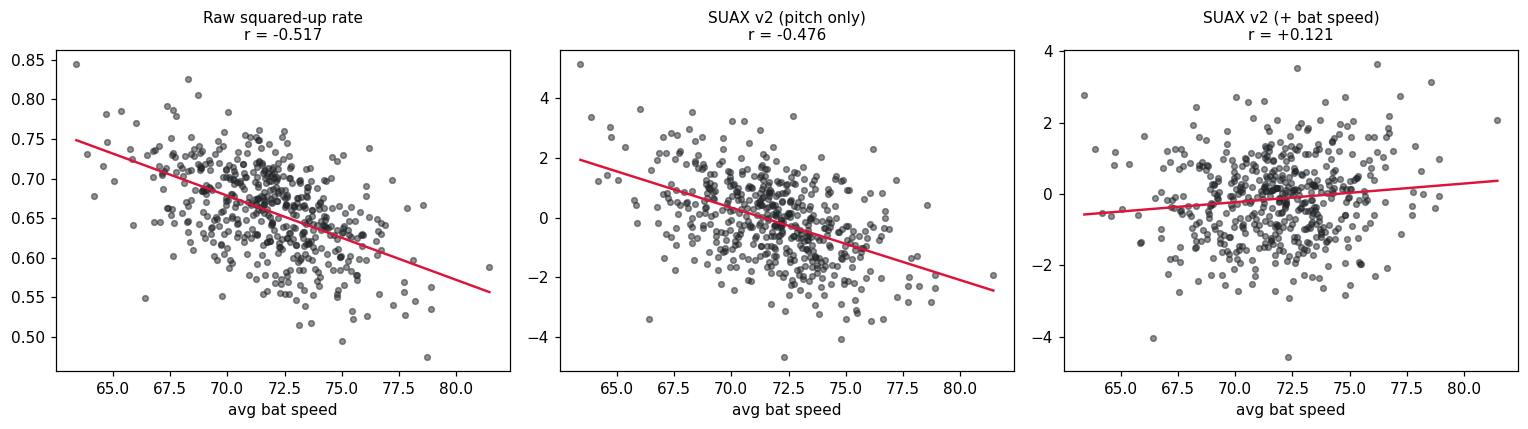

In [10]:
fig, ax = plt.subplots(1,3, figsize=(14,4))
for a,(c,t) in zip(ax, [("su_rate","Raw squared-up rate"),
                        ("suax_pitch_only_p100","SUAX v2 (pitch only)"),
                        ("suax_pitch_bs_p100","SUAX v2 (+ bat speed)")]):
    r = board["bat_speed"].corr(board[c])
    a.scatter(board["bat_speed"], board[c], s=14, alpha=.5, color="#212529")
    z = np.polyfit(board["bat_speed"], board[c], 1)
    xs = np.linspace(board["bat_speed"].min(), board["bat_speed"].max(), 20)
    a.plot(xs, np.polyval(z, xs), color="crimson", lw=1.6)
    a.set_title(f"{t}\nr = {r:+.3f}", fontsize=10); a.set_xlabel("avg bat speed")
plt.tight_layout(); plt.show()

## 8 · Fix #3 — year-over-year prediction

v1's marginal-value test was contaminated. It predicted **same-season** xwOBAcon, which is computed from exit velocity and launch angle — and squared-up % is exit velocity divided by a constant-ish denominator. `su_rate` was substantially predicting itself, which is why it posted a ΔR² of +0.15 while SUAX added +0.002.

The uncontaminated test uses season 1 to predict season 2. Two questions:

- **Reliability**: does the metric correlate with itself across seasons? (Is it a stable trait?)
- **Predictive value**: does season-1 SUAX beat season-1 raw squared-up rate at forecasting season-2 contact quality?

A metric that fails both is descriptive noise. A metric that passes reliability but not prediction is real but redundant.

In [11]:
years = sorted(bip["game_year"].dropna().unique().astype(int))
if len(years) < 2:
    print("Need >= 2 seasons for the year-over-year test - skipping.")
    yoy = None
else:
    y1, y2 = years[0], years[-1]
    def season(yr):
        s = bip[bip["game_year"]==yr]
        a = {"bbe":("squared_up_pct","size"), "su_rate":("squared_up","mean"),
             "su_pct":("squared_up_pct","mean"), "bat_speed":("bat_speed","mean"),
             "r_pitch_only":("resid_pitch_only","mean"), "r_pitch_bs":("resid_pitch_bs","mean")}
        if "estimated_woba_using_speedangle" in s.columns:
            a["xwobacon"] = ("estimated_woba_using_speedangle","mean")
        g = s.groupby("batter").agg(**a)
        return g[g["bbe"] >= MIN_BBE_YR]

    A, B = season(y1), season(y2)
    yoy = A.join(B, lsuffix="_1", rsuffix="_2", how="inner")
    print(f"{len(yoy)} hitters with >= {MIN_BBE_YR} BBE in both {y1} and {y2}\n")

    print("--- YEAR-OVER-YEAR RELIABILITY (metric_y1 vs metric_y2) ---")
    for lab, c in [("bat speed","bat_speed"), ("raw squared-up rate","su_rate"),
                   ("raw squared-up pct","su_pct"),
                   ("SUAX pitch only","r_pitch_only"), ("SUAX +bat speed","r_pitch_bs")]:
        print(f"  {lab:24s} r = {yoy[f'{c}_1'].corr(yoy[f'{c}_2']):+.3f}")

    if "xwobacon_2" in yoy.columns:
        print(f"\n--- PREDICTING {y2} xwOBAcon FROM {y1} ---")
        for lab, c in [("bat speed","bat_speed_1"), ("raw squared-up rate","su_rate_1"),
                       ("raw squared-up pct","su_pct_1"),
                       ("SUAX pitch only","r_pitch_only_1"), ("SUAX +bat speed","r_pitch_bs_1")]:
            print(f"  {lab:24s} r = {yoy[c].corr(yoy['xwobacon_2']):+.3f}")

        print(f"\n--- NESTED ΔR² (out-of-sample: {y1} features -> {y2} outcome) ---")
        from sklearn.linear_model import LinearRegression
        def R2(cs):
            X_ = yoy[cs].fillna(yoy[cs].mean()).values
            return LinearRegression().fit(X_, yoy["xwobacon_2"].values).score(X_, yoy["xwobacon_2"].values)
        prev = 0.0
        for lab, cs in [("bat speed", ["bat_speed_1"]),
                        ("+ raw squared-up rate", ["bat_speed_1","su_rate_1"]),
                        ("+ SUAX (pitch only)", ["bat_speed_1","su_rate_1","r_pitch_only_1"])]:
            v = R2(cs); print(f"  {lab:26s} R2={v:.4f}  dR2={v-prev:+.4f}"); prev = v

314 hitters with >= 80 BBE in both 2024 and 2025

--- YEAR-OVER-YEAR RELIABILITY (metric_y1 vs metric_y2) ---
  bat speed                r = +0.932
  raw squared-up rate      r = +0.652
  raw squared-up pct       r = +0.698
  SUAX pitch only          r = +0.691
  SUAX +bat speed          r = +0.665

--- PREDICTING 2025 xwOBAcon FROM 2024 ---
  bat speed                r = +0.645
  raw squared-up rate      r = -0.101
  raw squared-up pct       r = -0.130
  SUAX pitch only          r = -0.072
  SUAX +bat speed          r = +0.339

--- NESTED ΔR² (out-of-sample: 2024 features -> 2025 outcome) ---
  bat speed                  R2=0.4160  dR2=+0.4160
  + raw squared-up rate      R2=0.5074  dR2=+0.0914
  + SUAX (pitch only)        R2=0.5082  dR2=+0.0008


## 9 · Fix #4 — where the adjustment should matter (sample-size sweep)

**The reasoning.** Over a full season every qualified hitter faces roughly the same distribution of velocity, movement and location. The between-hitter variance in *average pitch difficulty faced* is therefore tiny, and a season-long adjustment has almost nothing to correct. That is the structural reason v1's ΔR² was ~0.

In small samples that stops being true. Across 80 batted balls a hitter can easily have drawn an unrepresentative run — a stretch against power bullpens, a lopsided platoon split, a homestand in a pitcher's park. There the "average pitch faced" genuinely differs between players, and removing it removes a real source of error.

**The test.** Draw random subsamples of size *n* from season 1, compute each metric, and correlate against the hitter's full season-2 contact quality. If the adjustment is worth anything, its advantage should grow as *n* shrinks.

  n=600: only 0 hitters have that many BBE - skipped
Correlation with 2025 xwOBAcon, by 2024 subsample size

  n BBE       raw      SUAX      edge
     40    -0.066    -0.055    +0.011
     80    -0.085    -0.060    +0.025
    150    -0.114    -0.085    +0.028
    300    -0.058    -0.037    +0.021
    600        --        --        --

A WIDENING edge as n shrinks = the metric belongs in small-sample work.
A flat or shrinking edge = the adjustment has no use case.


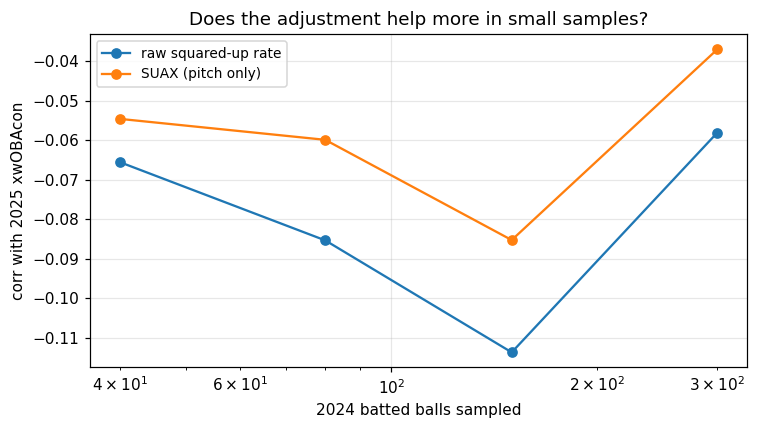

In [12]:
if yoy is not None and "xwobacon_2" in yoy.columns:
    SIZES, REPS = [40, 80, 150, 300, 600], 12
    s1 = bip[bip["game_year"]==y1]
    elig = yoy.index
    truth = yoy["xwobacon_2"]
    curves = {"raw squared-up rate": [], "SUAX (pitch only)": []}
    grouped = {b: g for b, g in s1[s1["batter"].isin(elig)].groupby("batter")}

    for n in SIZES:
        n_elig = sum(len(g) >= n for g in grouped.values())
        if n_elig < 20:
            for k in curves: curves[k].append(np.nan)
            print(f"  n={n}: only {n_elig} hitters have that many BBE - skipped")
            continue
        acc = {k: [] for k in curves}
        for rep in range(REPS):
            rng = np.random.default_rng(1000*rep + n)
            raw_v, adj_v, keep = [], [], []
            for b, g in grouped.items():
                if len(g) < n: continue
                idx = rng.choice(len(g), n, replace=False)
                sub = g.iloc[idx]
                raw_v.append(sub["squared_up"].mean())
                adj_v.append(sub["resid_pitch_only"].mean())
                keep.append(b)
            if len(keep) < 20: continue
            t = truth.loc[keep].values
            acc["raw squared-up rate"].append(np.corrcoef(raw_v, t)[0,1])
            acc["SUAX (pitch only)"].append(np.corrcoef(adj_v, t)[0,1])
        for k in curves:
            curves[k].append(np.mean(acc[k]) if acc[k] else np.nan)

    print(f"Correlation with {y2} xwOBAcon, by {y1} subsample size\n")
    print(f"{'n BBE':>7s} {'raw':>9s} {'SUAX':>9s} {'edge':>9s}")
    for i, n in enumerate(SIZES):
        r_, a_ = curves["raw squared-up rate"][i], curves["SUAX (pitch only)"][i]
        if np.isnan(r_): print(f"{n:>7d} {'--':>9s} {'--':>9s} {'--':>9s}")
        else: print(f"{n:>7d} {r_:>9.3f} {a_:>9.3f} {a_-r_:>+9.3f}")
    print("\nA WIDENING edge as n shrinks = the metric belongs in small-sample work.")
    print("A flat or shrinking edge = the adjustment has no use case.")

    plt.figure(figsize=(7,4))
    ok = [i for i,v in enumerate(curves["raw squared-up rate"]) if not np.isnan(v)]
    for k, v in curves.items():
        plt.plot([SIZES[i] for i in ok], [v[i] for i in ok], "o-", label=k)
    plt.xscale("log"); plt.xlabel(f"{y1} batted balls sampled")
    plt.ylabel(f"corr with {y2} xwOBAcon"); plt.legend(fontsize=9)
    plt.title("Does the adjustment help more in small samples?"); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print("Needs two seasons + xwOBAcon - skipping.")

## 10 · Fix #5 — the pitcher null, tested properly

v1 reported that pitcher-side spread was indistinguishable from noise. That was an observation, not a test. Here it becomes one.

**Variance decomposition.** Observed spread between pitchers is true-talent spread plus sampling noise:

$$\sigma^2_{\text{observed}} = \sigma^2_{\text{true}} + \overline{\sigma^2_{\text{within}}/n_i}$$

If $\sigma^2_{\text{observed}} \le \overline{\sigma^2_{\text{within}}/n_i}$ there is no evidence of any true spread.

**Permutation test.** Shuffle the residuals across pitchers, keeping every pitcher's batted-ball count fixed, and recompute the between-pitcher variance. That builds the null distribution of "what spread would we see if no pitcher had any skill." The p-value is the share of shuffles whose spread matches or exceeds the real one.

=== PITCHERS: is there any true spread in contact suppression? ===
  478 pitchers >= 150 BBE
  observed between-pitcher variance : 4.889e-05
  null mean (labels shuffled)       : 2.980e-05
  p-value                           : 0.0000
  -> REJECT null: real pitcher-level spread exists

=== HITTERS: same test, as a positive control ===
  498 hitters | observed 1.978e-04 | null mean 2.786e-05 | p = 0.0000
  -> REJECT null: real hitter-level spread exists


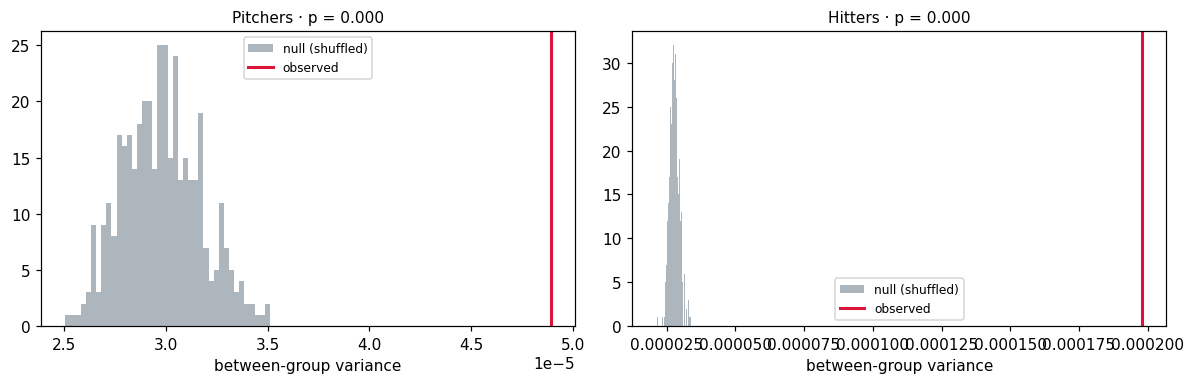

In [13]:
def permutation_spread_test(values, group_ids, min_n=MIN_BBE_P, n_perm=400, seed=RANDOM_SEED):
    d_ = pd.DataFrame({"v":values.values, "g":group_ids.values}).dropna()
    sz = d_.groupby("g")["v"].size()
    d_ = d_[d_["g"].isin(sz[sz>=min_n].index)]
    def spread(frame):
        m = frame.groupby("g")["v"].agg(["mean","size"])
        w = m["size"]/m["size"].sum()
        return float(np.average((m["mean"]-np.average(m["mean"],weights=w))**2, weights=w))
    obs = spread(d_)
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm)
    vals = d_["v"].values.copy()
    for i in range(n_perm):
        rng.shuffle(vals)
        null[i] = spread(pd.DataFrame({"v":vals, "g":d_["g"].values}))
    p = float((null >= obs).mean())
    return obs, null, p, d_["g"].nunique()

print("=== PITCHERS: is there any true spread in contact suppression? ===")
obs_p, null_p, pval_p, n_p = permutation_spread_test(bip["resid_pitch_bs"], bip["pitcher"])
print(f"  {n_p} pitchers >= {MIN_BBE_P} BBE")
print(f"  observed between-pitcher variance : {obs_p:.3e}")
print(f"  null mean (labels shuffled)       : {null_p.mean():.3e}")
print(f"  p-value                           : {pval_p:.4f}")
print("  -> " + ("REJECT null: real pitcher-level spread exists" if pval_p < 0.05
                 else "CANNOT reject null: spread is consistent with pure sampling noise"))

print("\n=== HITTERS: same test, as a positive control ===")
obs_h, null_h, pval_h, n_h = permutation_spread_test(bip["resid_pitch_bs"], bip["batter"], min_n=MIN_BBE)
print(f"  {n_h} hitters | observed {obs_h:.3e} | null mean {null_h.mean():.3e} | p = {pval_h:.4f}")
print("  -> " + ("REJECT null: real hitter-level spread exists" if pval_h < 0.05
                 else "CANNOT reject null"))

fig, ax = plt.subplots(1,2, figsize=(11,3.6))
for a,(nl,ob,pv,t) in zip(ax, [(null_p,obs_p,pval_p,"Pitchers"), (null_h,obs_h,pval_h,"Hitters")]):
    a.hist(nl, bins=40, color="#adb5bd", label="null (shuffled)")
    a.axvline(ob, color="crimson", lw=2, label="observed")
    a.set_title(f"{t} · p = {pv:.3f}", fontsize=10); a.legend(fontsize=8)
    a.set_xlabel("between-group variance")
plt.tight_layout(); plt.show()

In [14]:
# Pitcher leaderboard - report it, but read it in light of the test above.
pb = bip.groupby("pitcher").agg(bbe=("squared_up_pct","size"),
                                su_allowed=("squared_up","mean"),
                                r=("resid_pitch_bs","mean"),
                                velo=("plate_speed","mean"))
pb = pb[pb["bbe"] >= MIN_BBE_P].copy()
pb.insert(0, "name", label(pb.index) if NAME else pb.index.astype(str))
wv = float(bip["resid_pitch_bs"].var())
pb["suabe"], kp, vb, vs = shrink_cont(pb["r"], pb["bbe"], wv, "pitchers")
pb["suabe_p100"] = pb["suabe"]*100
print(f"\n{len(pb)} qualified pitchers | k={kp:.1f}")
display(pb.sort_values("suabe_p100")[["name","bbe","velo","su_allowed","suabe_p100"]].head(12).round(3))


478 qualified pitchers | k=1193.9


,name,bbe,velo,su_allowed,suabe_p100
pitcher,,,,,
642547,Freddy Peralta,795,82.331,0.625,-0.634
650633,Mike King,567,81.343,0.541,-0.592
686613,Hunter Brown,820,84.368,0.588,-0.492
663460,Kris Bubic,348,80.521,0.575,-0.483
671096,Andrew Abbott,820,80.748,0.617,-0.475
623211,Huascar Brazobán,275,85.249,0.527,-0.469
669373,Tarik Skubal,832,84.911,0.593,-0.423
622554,Seranthony Domínguez,278,86.052,0.594,-0.385
519242,Chris Sale,606,80.121,0.635,-0.383


In [17]:
from sklearn.linear_model import LinearRegression
 
assert yoy is not None and "xwobacon_2" in yoy.columns, "Run section 8 first."
 
def _R2(cols):
    X_ = yoy[cols].fillna(yoy[cols].mean()).values
    y_ = yoy["xwobacon_2"].values
    return LinearRegression().fit(X_, y_).score(X_, y_)
 
print(f"n = {len(yoy)} hitters | target: {y2} xwOBAcon | features from {y1}\n")
 
# Orthogonality check first: if suax_pitch_bs is near-orthogonal to bat speed,
# any R2 it adds is genuinely new information rather than repackaged bat speed.
print("--- collinearity with bat speed (want |r| near 0 for pitch_bs) ---")
for lab, c in [("raw squared-up rate", "su_rate_1"),
               ("SUAX pitch only",     "r_pitch_only_1"),
               ("SUAX + bat speed",    "r_pitch_bs_1")]:
    print(f"  {lab:22s} r vs bat speed = {yoy['bat_speed_1'].corr(yoy[c]):+.3f}")
 
print("\n--- NESTED ΔR² ---")
steps = [
    ("bat speed",             ["bat_speed_1"]),
    ("+ raw squared-up rate", ["bat_speed_1", "su_rate_1"]),
    ("+ SUAX (pitch only)",   ["bat_speed_1", "su_rate_1", "r_pitch_only_1"]),
    ("+ SUAX (+bat speed)",   ["bat_speed_1", "su_rate_1", "r_pitch_only_1", "r_pitch_bs_1"]),
]
prev = 0.0
for lab, cols in steps:
    v = _R2(cols)
    print(f"  {lab:24s} R2 = {v:.4f}   dR2 = {v - prev:+.4f}")
    prev = v
 
# Cleaner framing: bat speed + the working variant only, no redundant terms.
print("\n--- parsimonious model ---")
a, b = _R2(["bat_speed_1"]), _R2(["bat_speed_1", "r_pitch_bs_1"])
print(f"  bat speed alone            R2 = {a:.4f}")
print(f"  bat speed + SUAX(+bs)      R2 = {b:.4f}   dR2 = {b - a:+.4f}")
print(f"\n  -> {'SUAX adds real signal' if b - a > 0.02 else 'SUAX adds little'} "
      f"over bat speed alone.")

n = 314 hitters | target: 2025 xwOBAcon | features from 2024

--- collinearity with bat speed (want |r| near 0 for pitch_bs) ---
  raw squared-up rate    r vs bat speed = -0.548
  SUAX pitch only        r vs bat speed = -0.468
  SUAX + bat speed       r vs bat speed = +0.150

--- NESTED ΔR² ---
  bat speed                R2 = 0.4160   dR2 = +0.4160
  + raw squared-up rate    R2 = 0.5074   dR2 = +0.0914
  + SUAX (pitch only)      R2 = 0.5082   dR2 = +0.0008
  + SUAX (+bat speed)      R2 = 0.5107   dR2 = +0.0024

--- parsimonious model ---
  bat speed alone            R2 = 0.4160
  bat speed + SUAX(+bs)      R2 = 0.4758   dR2 = +0.0598

  -> SUAX adds real signal over bat speed alone.



Correlation with 2025 xwOBAcon, by 2024 subsample size

  n BBE   raw squared-up rate     SUAX (pitch only)    SUAX (+ bat speed)
     40                -0.066                -0.055                 0.236
     80                -0.085                -0.060                 0.283
    150                -0.114                -0.085                 0.328
    300                -0.058                -0.037                 0.468

Read it this way:
  * Sign matters more than slope. A metric with a NEGATIVE correlation is
    predicting next-year contact quality backwards and is unusable at any n.
  * Among metrics with the right sign, a curve that stays flat as n shrinks
    is robust in small samples — that is the prospect / in-season use case.


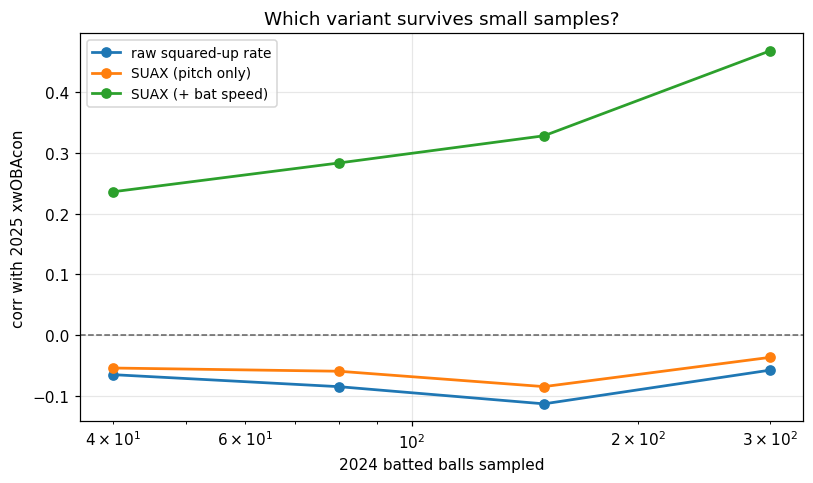

In [18]:
import numpy as np
import matplotlib.pyplot as plt
 
SIZES, REPS = [40, 80, 150, 300], 12
SERIES = {
    "raw squared-up rate": "squared_up",
    "SUAX (pitch only)":   "resid_pitch_only",
    "SUAX (+ bat speed)":  "resid_pitch_bs",
}
 
s1 = bip[bip["game_year"] == y1]
truth = yoy["xwobacon_2"]
grouped = {b_: g for b_, g in s1[s1["batter"].isin(yoy.index)].groupby("batter")}
curves = {k: [] for k in SERIES}
 
for n in SIZES:
    n_elig = sum(len(g) >= n for g in grouped.values())
    if n_elig < 20:
        for k in curves:
            curves[k].append(np.nan)
        print(f"  n={n}: only {n_elig} hitters qualify — skipped")
        continue
    acc = {k: [] for k in SERIES}
    for rep in range(REPS):
        rng = np.random.default_rng(1000 * rep + n)
        vals = {k: [] for k in SERIES}
        keep = []
        for b_, g in grouped.items():
            if len(g) < n:
                continue
            sub = g.iloc[rng.choice(len(g), n, replace=False)]
            for k, col in SERIES.items():
                vals[k].append(sub[col].mean())
            keep.append(b_)
        if len(keep) < 20:
            continue
        t = truth.loc[keep].values
        for k in SERIES:
            acc[k].append(np.corrcoef(vals[k], t)[0, 1])
    for k in curves:
        curves[k].append(np.mean(acc[k]) if acc[k] else np.nan)
 
hdr = f"{'n BBE':>7s}" + "".join(f"{k:>22s}" for k in SERIES)
print(f"\nCorrelation with {y2} xwOBAcon, by {y1} subsample size\n")
print(hdr)
for i, n in enumerate(SIZES):
    row = f"{n:>7d}"
    for k in SERIES:
        v = curves[k][i]
        row += f"{'--':>22s}" if np.isnan(v) else f"{v:>22.3f}"
    print(row)
 
print("\nRead it this way:")
print("  * Sign matters more than slope. A metric with a NEGATIVE correlation is")
print("    predicting next-year contact quality backwards and is unusable at any n.")
print("  * Among metrics with the right sign, a curve that stays flat as n shrinks")
print("    is robust in small samples — that is the prospect / in-season use case.")
 
plt.figure(figsize=(7.5, 4.5))
ok = [i for i, v in enumerate(curves["raw squared-up rate"]) if not np.isnan(v)]
for k, v in curves.items():
    plt.plot([SIZES[i] for i in ok], [v[i] for i in ok], "o-", lw=1.8, label=k)
plt.axhline(0, color="k", lw=1, ls="--", alpha=.6)
plt.xscale("log")
plt.xlabel(f"{y1} batted balls sampled")
plt.ylabel(f"corr with {y2} xwOBAcon")
plt.legend(fontsize=9)
plt.title("Which variant survives small samples?")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

## 11 · Export

In [15]:
board.round(4).to_csv("suax_v2_hitters.csv")
pb.round(4).to_csv("suax_v2_pitchers.csv")
if yoy is not None: yoy.round(4).to_csv("suax_v2_yoy.csv")
keep = ["batter","pitcher","game_year","squared_up","squared_up_pct","bat_speed","plate_speed",
        "xpct_pitch_only","xpct_pitch_bs","resid_pitch_only","resid_pitch_bs"]
bip[[c for c in keep if c in bip.columns]].round(4).to_csv("suax_v2_pitch_level.csv", index=False)
try:
    from google.colab import files; files.download("suax_v2_hitters.csv")
except Exception: pass
print("exported")

exported


---
## How to read the results

**The verdict lives in section 8.** If season-1 SUAX beats season-1 raw squared-up rate at predicting season-2 xwOBAcon, the metric is real. If it doesn't, the pitch-difficulty adjustment adds nothing at the season level and you should stop here — that is a legitimate finding, not a failure.

**Section 9 is the appeal.** Even if the full-season adjustment is worthless, a widening edge at small *n* means the metric belongs in prospect and in-season work rather than on a season leaderboard. A flat gap means the adjustment has no use case at all.

**Section 10 has two possible readings.** If the pitcher p-value is non-significant while the hitter control is significant, you've shown the test has power and pitchers genuinely lack repeatable skill here. If *both* come back non-significant, the test lacks power and you need more seasons before concluding anything.

## Remaining limitations

- **Fouls are still invisible.** Public Statcast has no `launch_speed` on foul balls, so this measures barrel accuracy conditional on putting the ball in play. A hitter who fouls off what he can't barrel is flattered.
- **Bat speed is measured at contact,** so it is partly a timing artifact — contact further out front means more distance to accelerate. Adding `intercept_ball_minus_batter_pos_y_inches` as a feature would absorb some of this; worth a variant.
- **Sequencing is unmodelled.** Every pitch is independent. Previous pitch type and velocity differential are the obvious extension and the most plausible route to finding pitcher-side signal.
- **The 1.23/0.23 formula ignores bat mass and moment of inertia,** so hitters on unusual bat profiles (torpedo bats especially) will be systematically off.